# Time Series Data Analysis

- [1.0 Introduction](#1.0-Introduction)
- [2.0 Data Understanding](#2.0-Data-Understanding)
- [3.0 Train-test Split](#3.0-Train-test-Split)
- [4.0 Data Analysis](#4.0-Data-Analysis)
    - [4.1 Seasonality Analysis](#4.1-Seasonality-Analysis)
- [Next Steps](#Next-Steps)

## 1.0 Introduction
The goal is to analyze time-series data to identify trends and seasonality, as well as to examine relationships between various time series data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

## 2.0 Data Understanding

The data used in this project is a time-series data capturing weekly shipping cost of ocean freight over time. Refer to as the 'Scaled Index Rate' subsequently.

In [2]:
data_dir = Path('./data')

# Load data
df = pd.read_csv(data_dir / 'ocean_freight_shipping_cost.csv')

# Sort the data chronologically from the earliest to the latest date
df['week'] = pd.to_datetime(df['week'])
df = df.sort_values(by='week').reset_index(drop=True)

print("The data span from {} to {}".format(df['week'].min(), df['week'].max()))

The data span from 2016-10-07 00:00:00 to 2024-11-01 00:00:00


### 2.1 Are There Any Missing Values in the Data?

In [3]:
print("Number of missing values in the data: {}".format(df['scaled_index_rate'].isna().sum()))

Number of missing values in the data: 0


### 2.2 Are There Missing, Additional, or Duplicate Entries in the Time Series Data?

The test is conducted by measuring the number of days difference between two consecutive dates. If there are no missing, additional, or duplicate entries, the difference between each pair of consecutive dates should be 7 days

In [4]:
# Compute the day difference between consecutive dates
df['time_diff'] = df['week'].diff().dt.days

# Get all the rows with time differences that are not equal to 7 days
idx = df[(df['time_diff'] != 7) & (df['time_diff'].notna())].index

# Get the rows with the previous date
idx = idx.append(idx - 1).sort_values()

df.loc[idx]

,week,scaled_index_rate,time_diff
287,2022-04-08,428.212611,7.0
288,2022-04-22,421.881845,14.0
293,2022-05-27,362.265599,7.0
294,2022-06-10,335.032233,14.0


Findings: There are two set of consecutive dates with 14 gaps, suggesting that there are two missing weeks. Missing Friday is 2022-04-15, 2022-06-03. 

Next Step: Since these values are not expected to be missing, they will be imputed using forward fill, i.e. assigning the previous week’s value to the missing entry. This method is chosen for its simplicity and the assumption that the values do not change significantly from the previous week. Data leakage is also prevented.


#### 2.2.1 Data Imputation

In [5]:
# Drop time_diff
if 'time_diff' in df.columns:
    df = df.drop(columns=['time_diff'])

# Add missing entries
df_missing_values = pd.DataFrame({
    'week': [pd.to_datetime('2022-04-15'), pd.to_datetime('2022-06-03')],
    'scaled_index_rate': [None, None]
})

df_imputed = pd.concat([df, df_missing_values]).sort_values(by='week', ignore_index=False)

# Forward fill the missing values
df_imputed['scaled_index_rate'] = df_imputed['scaled_index_rate'].ffill()

In [6]:
# Confirm imputation is performed correctly
assert df_imputed['week'].diff().dt.days.dropna().unique() == [7]

df_imputed[df_imputed['week'].isin(['2022-04-08', '2022-04-15', '2022-05-27', '2022-06-03'])]

,week,scaled_index_rate
287,2022-04-08,428.212611
0,2022-04-15,428.212611
293,2022-05-27,362.265599
1,2022-06-03,362.265599


### 2.3 Any abnormal values in the dataset

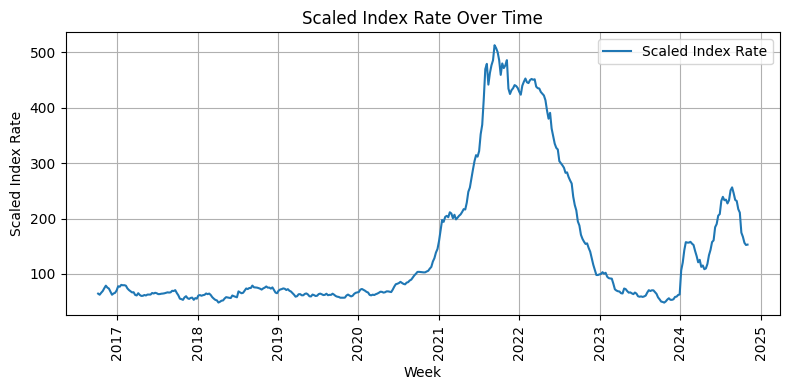

In [7]:
# Vizualise scaled index rate over time
plt.figure(figsize=(8, 4))
plt.plot(df['week'], df['scaled_index_rate'], label='Scaled Index Rate')
plt.title('Scaled Index Rate Over Time')
plt.xlabel('Week')
plt.xticks(rotation=90)
plt.ylabel('Scaled Index Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()

Findings:
- No abnormal values
- Before mid-2020: Scaled Index Rate fluctuates around 60 to 70, which is approximately 2 to 4 times lower than the recent values
- Between mid-2020 to late 2021: Scaled Index Rate rose rapidly, peaking at around 500. It was very likely due to Covid-19 pandemic
- Late 2021 to early 2023: Scaled Index Rate remained at an all-time high level until early 2022, after which it declined rapidly. It could be due to COVID-19 pandemic coming under control as vaccination rates increased
- Early 2023 to early 2024: Scaled Index Rate gradually declined and stabilized around its pre-pandemic levels
- Early 2024 onwards: Scaled Index Rate began to rise, with a brief dip followed by another rise before a recent dip again. It could be driven by geopolitical tensions, such as Russia–Ukraine war


## 3.0 Train-test Split

Before conducting any data analysis and model training, the dataset is first divided into training and testing sets to prevent biases and data leakage. All data analysis and model development are performed using the training data only.

The dataset is chronologically split by year to prevent lookahead bias. Specifically, a roughly 75-25 split is applied, with data from 2016 to 2023 (6 years) used for training, and data from 2023 to 2025 (2 years) used for testing. This also helps to ensure that full-year seasonality patterns are preserved in both the training and testing sets.

In [8]:
train_test_split_date = '2023-01-01'
df_train = df_imputed[df_imputed['week'] < train_test_split_date]
df_test = df_imputed[df_imputed['week'] >= train_test_split_date]
print("Train-test split ratio: {:.2f}% train, {:.2f}% test".format(
    len(df_train) / len(df) * 100,
    len(df_test) / len(df) * 100
))

Train-test split ratio: 77.62% train, 22.86% test


## 4.0 Data Analysis

### 4.1 Seasonality Analysis

The objective is to identify any seasonal patterns in the data <br>

Given the significant changes in Scaled Index Rate after COVID-19 pandemic, the data will be analyzed in two separate periods: 2016–2020 (pre-COVID) and 2020–2023 (during/post-COVID). This will allow clearer observation of any seasonality in these two different periods

In [9]:
# Add additional time features
df_train['month'] = df_train['week'].dt.month
df_train['year'] = df_train['week'].dt.year

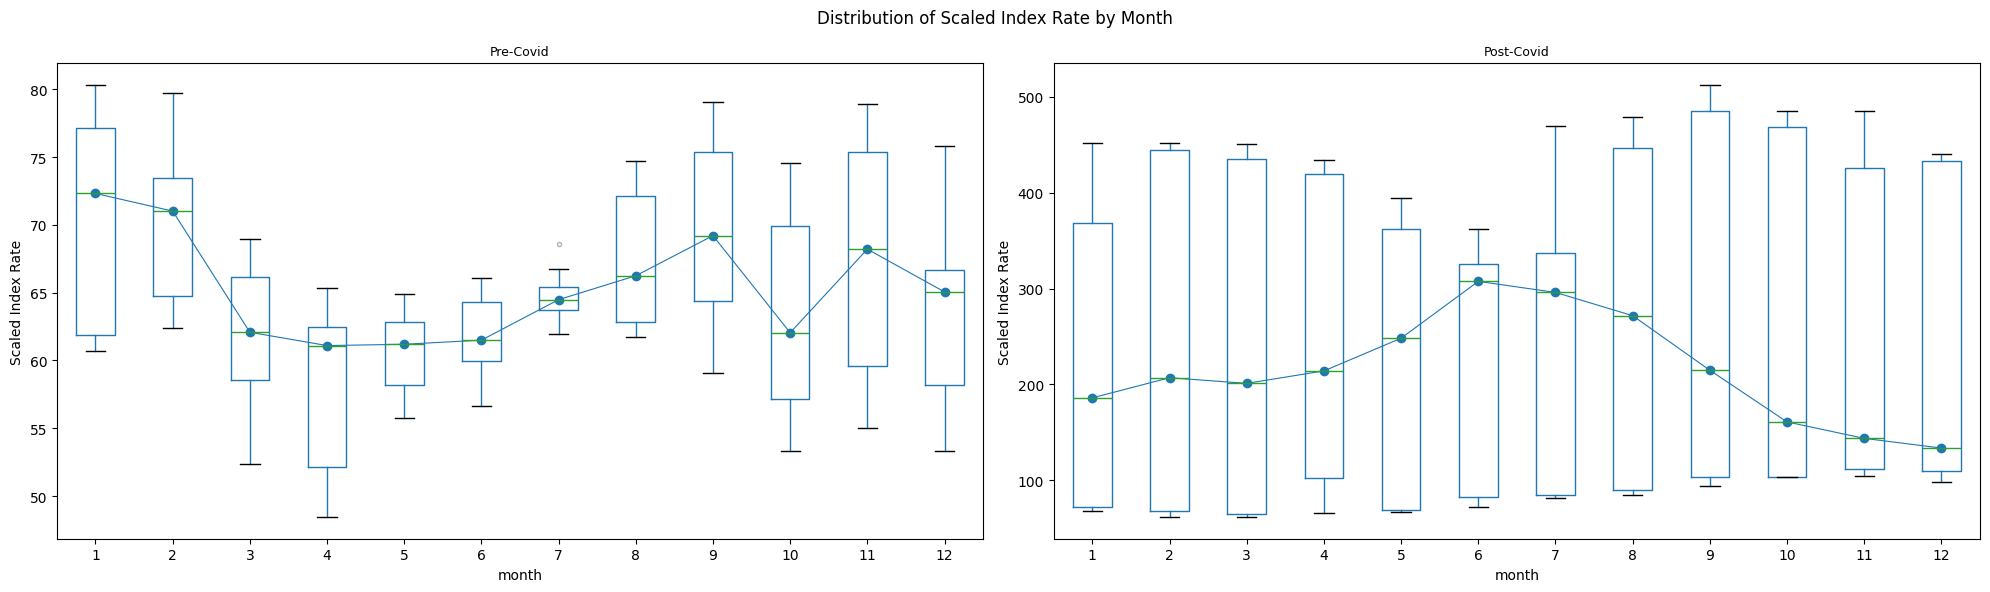

In [10]:
# Define pre-COVID and post-COVID ranges
pre_covid_range = range(2016, 2020)
post_covid_range = range(2020, 2023)

fig, axs = plt.subplots(1, 2, figsize=(20, 6), sharex=False, sharey=False)
axs = axs.ravel()

# Pre-COVID distribution by month 
i = 0
df_temp = df_train[df_train['year'].isin(pre_covid_range)]
df_temp.boxplot(column='scaled_index_rate', by='month', ax=axs[i], flierprops={'markersize': 3, 'alpha': 0.3})
df_temp.groupby('month')['scaled_index_rate'].median().plot(style='o-', linewidth=0.8, ax=axs[i])
axs[i].set_ylabel('Scaled Index Rate')
axs[i].set_title('Pre-Covid', fontsize=9);

# Post-COVID distribution by month
i += 1
df_temp = df_train[df_train['year'].isin(post_covid_range)]
df_temp.boxplot(column='scaled_index_rate', by='month', ax=axs[i], flierprops={'markersize': 3, 'alpha': 0.3})
df_temp.groupby('month')['scaled_index_rate'].median().plot(style='o-', linewidth=0.8, ax=axs[i])
axs[i].set_ylabel('Scaled Index Rate')
axs[i].set_title('Post-Covid', fontsize=9);

fig.suptitle("Distribution of Scaled Index Rate by Month", fontsize=12)
fig.tight_layout()

Key Findings:
- Pre-Covid: The median value follows a U-shaped pattern, with lower values from March to June and higher values at the beginning and end of the year
- Post-Covid: The median value follows an inverted U-shaped pattern, with lower values from June to August and lower values at the beginning and end of the year
- Comparison of Pre-COVID vs Post-COVID:
    - There is clear shift in seasonal pattern, indicating using past data to forecast trends post-Covid is not feasible
    - More variability in Scaled Index Rate post-Covid, suggesting that it is more challenging to use past values to forecast the future values accurately

Findings:
1. Pre-covid: There is a seasonality observed for week of year
2. Post-covid: More variation in the data

Post covid: Why is 15 and 22 so low? Because of missing value

## Next Steps
- Identify related public time-series data to analyse the trends
- Research statistical techniques to understand the relationship between the public data vs Scaled Index Rate